In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
df <- read.csv("processed_wine_quality.csv")


In [4]:
install.packages("MASS")
install.packages("klaR")
install.packages("readxl")
install.packages("Hotelling")

library(MASS)
library(klaR)
library(readxl)
library(Hotelling)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘proxy’, ‘R.cache’, ‘e1071’, ‘styler’, ‘classInt’, ‘labelled’, ‘combinat’, ‘questionr’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘corpcor’



Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: corpcor


Attaching package: ‘Hotelling’


The following object is masked from ‘package:dplyr’:

    summarise




In [5]:
install.packages("biotools")
library(biotools)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

---
biotools version 4.3



In [6]:
numeric_cols <- names(df)[sapply(df, is.numeric)]
predictors <- df[, numeric_cols]

boxM(predictors, df$quality_group)


	Box's M-test for Homogeneity of Covariance Matrices

data:  predictors
Chi-Sq (approx.) = 1487.8, df = 132, p-value < 2.2e-16


In [7]:
wine_qual <- qda(quality_group~.,data = df)
wine_qual

Call:
qda(quality_group ~ ., data = df)

Prior probabilities of groups:
       High         Low      Medium 
0.202038770 0.002339572 0.795621658 

Group means:
       fixed_acidity volatile_acidity citric_acid residual_sugar   chlorides
High     -0.14392536     -0.359108326  0.13028210    -0.07329391 -0.38422941
Low       0.16749971      0.591341334 -0.42602642    -0.14753610  0.12237942
Medium   -0.02017596      0.008355079 -0.07976996     0.04731192 -0.05263149
       free_sulfur_dioxide total_sulfur_dioxide    density           pH
High            0.14683168           0.02781970 -0.5862136  0.029692299
Low            -0.20533075          -0.17920875  0.1386438  0.343234405
Medium          0.05180031           0.06230343  0.1067407 -0.004018578
         sulphates     alcohol
High   -0.02298673  0.74802608
Low    -0.10689883 -0.09386444
Medium -0.07394677 -0.20067329

In [8]:
manova_res <- manova(
  as.matrix(df[,1:11]) ~ quality_group,
  data = df
)

summary(manova_res, test = "Wilks")

                Df   Wilks approx F num Df den Df    Pr(>F)    
quality_group    2 0.80506   62.159     22  11942 < 2.2e-16 ***
Residuals     5981                                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [9]:
TukeyHSD(aov(fixed_acidity ~ quality_group, data = df))

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = fixed_acidity ~ quality_group, data = df)

$quality_group
                  diff         lwr       upr     p adj
Low-High     0.3114251 -0.25798568 0.8808358 0.4053063
Medium-High  0.1237494  0.05552896 0.1919698 0.0000637
Medium-Low  -0.1876757 -0.75464972 0.3792984 0.7178107


In [10]:
numeric_cols <- names(df)[sapply(df, is.numeric)]
df$quality_group <- factor(df$quality_group, levels=c("Low","Medium","High"))

variables <- c()
f_values <- c()
p_values <- c()
mean_low <- c()
mean_mid <- c()
mean_high <- c()

for (var in numeric_cols) {
  formula <- as.formula(paste(var, "~ quality_group"))
  aov_res <- aov(formula, data = df)

  s <- summary(aov_res)[[1]]
  variables <- c(variables, var)
  f_values  <- c(f_values, s["quality_group", "F value"])
  p_values  <- c(p_values, s["quality_group", "Pr(>F)"])

  means <- tapply(df[[var]], df$quality_group, mean)
  mean_low  <- c(mean_low, means["Low"])
  mean_mid  <- c(mean_mid, means["Medium"])
  mean_high <- c(mean_high, means["High"])
}

contrib_table <- data.frame(
  variable = variables,
  F_value  = f_values,
  p_value  = p_values,
  mean_low  = mean_low,
  mean_mid  = mean_mid,
  mean_high = mean_high
)

contrib_table <- contrib_table[order(-contrib_table$F_value), ]
contrib_table


,variable,F_value,p_value,mean_low,mean_mid,mean_high
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11,alcohol,530.851463,5.990621e-213,-0.09386444,-0.200673288,0.74802608
8,density,273.217534,2.847274e-114,0.13864379,0.106740659,-0.58621364
5,chlorides,140.644146,2.050450e-60,0.12237942,-0.052631493,-0.38422941
2,volatile_acidity,79.331907,9.900461e-35,0.59134133,0.008355079,-0.35910833
3,citric_acid,26.244005,4.488428e-12,-0.42602642,-0.079769958,0.13028210
1,fixed_acidity,9.428744,8.158124e-05,0.16749971,-0.020175955,-0.14392536
4,residual_sugar,7.210411,7.452932e-04,-0.14753610,0.047311923,-0.07329391
6,free_sulfur_dioxide,5.677365,3.441038e-03,-0.20533075,0.051800308,0.14683168
10,sulphates,1.587250,2.045733e-01,-0.10689883,-0.073946773,-0.02298673


In [11]:
g_wilks <- greedy.wilks(quality_group~.,data = df)
g_wilks

Formula containing included variables: 

quality_group ~ alcohol + volatile_acidity + residual_sugar + 
    sulphates + density + total_sulfur_dioxide + free_sulfur_dioxide + 
    fixed_acidity + pH
<environment: 0x59a189902da0>


Values calculated in each step of the selection procedure: 

                  vars Wilks.lambda F.statistics.overall p.value.overall
1              alcohol    0.8492478            530.85146   5.990621e-213
2     volatile_acidity    0.8296788            292.58662   1.855289e-240
3       residual_sugar    0.8241528            202.34829   1.225184e-246
4            sulphates    0.8182119            157.70149   1.120127e-253
5              density    0.8173577            126.83052   7.953685e-253
6 total_sulfur_dioxide    0.8153259            107.04625   6.308989e-254
7  free_sulfur_dioxide    0.8124051             93.43636   1.647911e-256
8        fixed_acidity    0.8104972             82.71768   1.480680e-257
9                   pH    0.8055339             75.

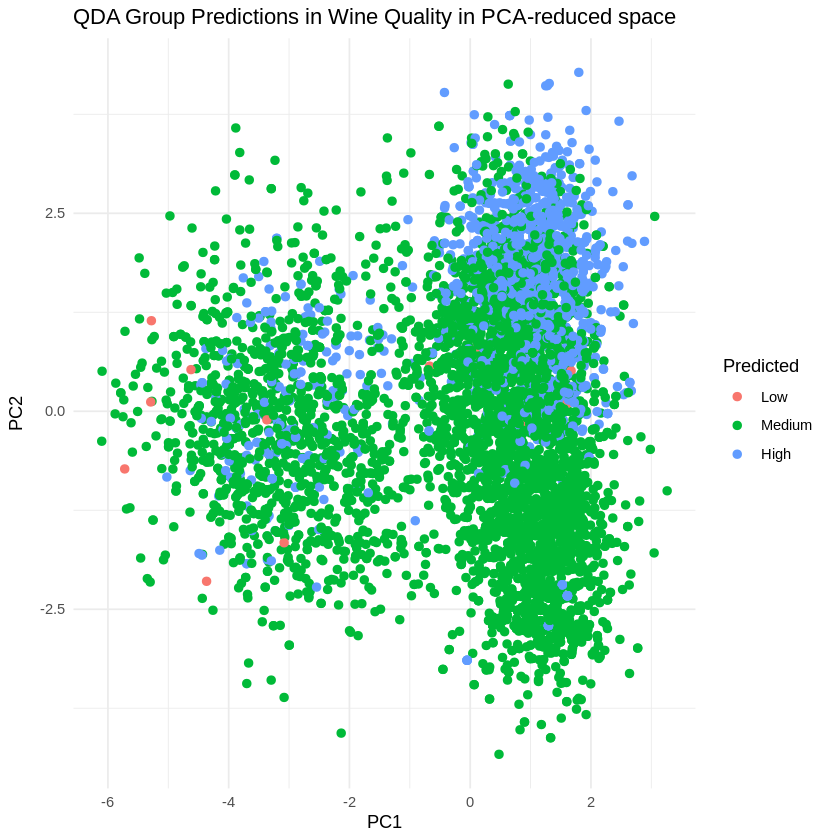

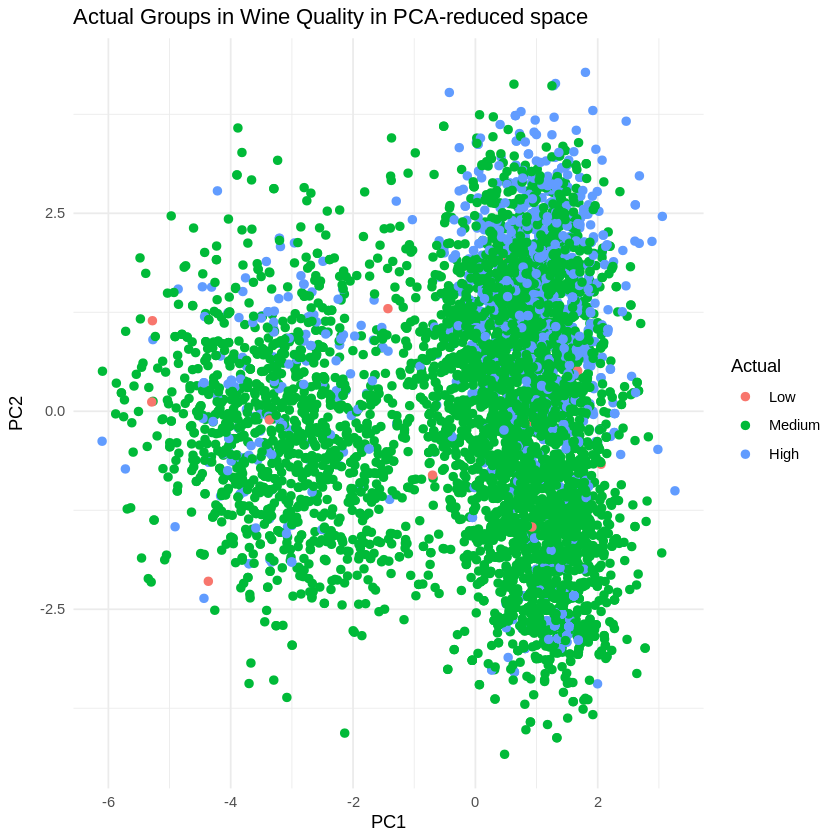

In [12]:
qda_model <- qda(quality_group ~ ., data = df)
pred <- predict(qda_model)

df$Predicted <- pred$class

pca <- prcomp(df[, sapply(df, is.numeric)], scale. = TRUE)
scores <- as.data.frame(pca$x[,1:2])
scores$Predicted <- df$Predicted
scores$Actual <- df$quality_group

ggplot(scores, aes(x = PC1, y = PC2, color = Predicted)) +
  geom_point(size = 2) +
  labs(title = "QDA Group Predictions in Wine Quality in PCA-reduced space") +
  theme_minimal()

ggplot(scores, aes(x = PC1, y = PC2, color = Actual)) +
  geom_point(size = 2) +
  labs(title = "Actual Groups in Wine Quality in PCA-reduced space") +
  theme_minimal()

In [14]:
install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




In [17]:
library(caret)
confusionMatrix(df$Predicted, df$quality_group)

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




Confusion Matrix and Statistics

          Reference
Prediction  Low Medium High
    Low       6      5    1
    Medium    7   4124  504
    High      1    632  704

Overall Statistics
                                          
               Accuracy : 0.8078          
                 95% CI : (0.7976, 0.8177)
    No Information Rate : 0.7956          
    P-Value [Acc > NIR] : 0.009680        
                                          
                  Kappa : 0.4324          
                                          
 Mcnemar's Test P-Value : 0.002038        

Statistics by Class:

                     Class: Low Class: Medium Class: High
Sensitivity            0.428571        0.8662      0.5823
Specificity            0.998995        0.5822      0.8674
Pos Pred Value         0.500000        0.8898      0.5266
Neg Pred Value         0.998660        0.5278      0.8913
Prevalence             0.002340        0.7956      0.2020
Detection Rate         0.001003        0.6892      0.1176

In [19]:
library(caret)
print(confusionMatrix(df$Predicted, df$quality_group))

Confusion Matrix and Statistics

          Reference
Prediction  Low Medium High
    Low       6      5    1
    Medium    7   4124  504
    High      1    632  704

Overall Statistics
                                          
               Accuracy : 0.8078          
                 95% CI : (0.7976, 0.8177)
    No Information Rate : 0.7956          
    P-Value [Acc > NIR] : 0.009680        
                                          
                  Kappa : 0.4324          
                                          
 Mcnemar's Test P-Value : 0.002038        

Statistics by Class:

                     Class: Low Class: Medium Class: High
Sensitivity            0.428571        0.8662      0.5823
Specificity            0.998995        0.5822      0.8674
Pos Pred Value         0.500000        0.8898      0.5266
Neg Pred Value         0.998660        0.5278      0.8913
Prevalence             0.002340        0.7956      0.2020
Detection Rate         0.001003        0.6892      0.1176